| Property | Value |
|----------|-------|
| Base model | YOLOv8n (nano) by Ultralytics |
| Framework | PyTorch |
| Parameters | ~3 million |
| Input size | 416 × 416 pixels |
| Pre-trained on | COCO (80 classes) → **transfer learning** |
| Fine-tuned on | Vehicles-OpenImages (5 classes, 627 images) |

## 0. Setup & imports

In [395]:
import sys
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from model import load_model, CLASS_NAMES, TEST_IMAGES, TRAIN_IMAGES, VAL_IMAGES, IMG_SIZE, CONFIDENCE_THRESHOLD

CLASS_COLORS = {
    "Ambulance":  "#ff1900",
    "Bus":        "#0099ff", 
    "Car":        "#00ff6a",  
    "Motorcycle": "#f39c12",
    "Truck":      "#b700ff",
}

training_dir = PROJECT_ROOT / "runs" / "vehicle_detection_balanced_100ep"
test_image = "8426440240c36e50_jpg.rf.DTljEZ5YN68SKKRpDN91.jpg"

## 1. The dataset

In [396]:
print(f"Train images: {len(list((TRAIN_IMAGES).iterdir()))}")
print(f"Validation images: {len(list((VAL_IMAGES).iterdir()))}")
print(f"Test images: {len(list((TEST_IMAGES).iterdir()))}")

Train images: 878
Validation images: 250
Test images: 126


In [414]:
sample_img = sorted(TEST_IMAGES.glob("*.jpg"))[42]
sample_label = sample_img.parent.parent / "labels" / sample_img.name.replace(".jpg", ".txt")

print(f"Image: {sample_img.name}")
print(f"Label: {sample_label.name}")
print()

if sample_label.exists():
    print(f"{'Class ID':<10} {'Center X':>10} {'Center Y':>10} {'Width':>10} {'Height':>10}  → Class name")
    print("-" * 75)
    with open(sample_label) as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            cx, cy, w, h = [float(x) for x in parts[1:]]
            print(f"{cls_id:<10} {cx:>10.3f} {cy:>10.3f} {w:>10.3f} {h:>10.3f}  → {CLASS_NAMES[cls_id]}")
    print()
else:
    print("(Label file not found for this image)")

Image: 6bc019fc59fce6bc_jpg.rf.VJAhyBJnfIldtscisZ3p.jpg
Label: 6bc019fc59fce6bc_jpg.rf.VJAhyBJnfIldtscisZ3p.txt

Class ID     Center X   Center Y      Width     Height  → Class name
---------------------------------------------------------------------------
2               0.119      0.746      0.150      0.065  → Car
2               0.171      0.542      0.126      0.059  → Car
2               0.462      0.220      0.343      0.144  → Car
2               0.464      0.513      0.300      0.184  → Car
2               0.469      0.779      0.290      0.194  → Car
2               0.478      0.028      0.240      0.055  → Car



---
## 1b. Exploratory Data Analysis (EDA)

In [398]:
from collections import defaultdict

TRAIN_LABELS = PROJECT_ROOT / "data" / "train" / "labels"

# Deduplicate: group by base name (before '_jpg.rf.'), keep first
groups = defaultdict(list)
for f in sorted(TRAIN_LABELS.glob("*.txt")):
    base = f.name.split("_jpg.rf.")[0]
    groups[base].append(f)

unique_label_files = [files[0] for files in groups.values()]

all_annotations = []
annots_per_image = {}

for lf in unique_label_files:
    count = 0
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(parts[0])
            cx, cy, w, h = [float(x) for x in parts[1:]]
            all_annotations.append({
                "class_name": CLASS_NAMES[cls_id],
                "cx": cx, "cy": cy, "w": w, "h": h,
                "area": w * h,
            })
            count += 1
    annots_per_image[lf.name] = count

print(f"Unique training images: {len(unique_label_files)}")
print(f"Total annotations: {len(all_annotations)}")

Unique training images: 439
Total annotations: 838


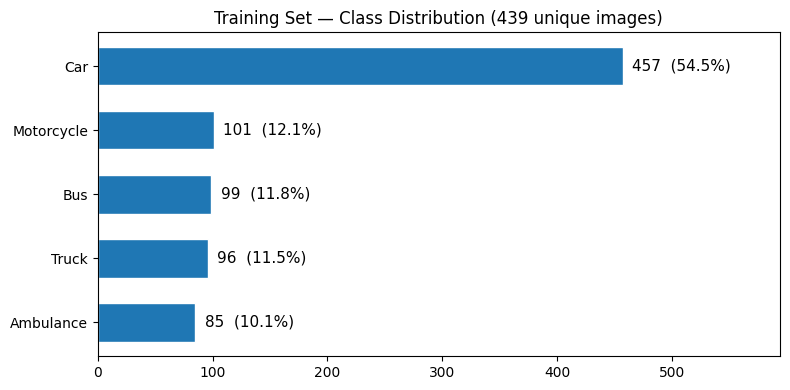


Class            Count   Percentage   Ratio to min
--------------------------------------------------
Ambulance           85        10.1%           1.0x
Bus                 99        11.8%           1.2x
Car                457        54.5%           5.4x
Motorcycle         101        12.1%           1.2x
Truck               96        11.5%           1.1x
--------------------------------------------------
TOTAL              838

Imbalance ratio (max/min): 5.4x


In [399]:
class_counts = Counter(a["class_name"] for a in all_annotations)
total = sum(class_counts.values())
min_count = min(class_counts.values())

sorted_classes = sorted(class_counts.keys(), key=lambda c: class_counts[c])
counts = [class_counts[c] for c in sorted_classes]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sorted_classes, counts, edgecolor="white", height=0.6)

for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f"{count}  ({pct:.1f}%)", va="center", fontsize=11)

ax.set_title(f"Training Set — Class Distribution ({len(unique_label_files)} unique images)")
ax.set_xlim(0, max(counts) * 1.3)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Class':<15} {'Count':>6} {'Percentage':>12} {'Ratio to min':>14}")
print("-" * 50)
for cls in CLASS_NAMES:
    c = class_counts[cls]
    pct = c / total * 100
    ratio = c / min_count
    print(f"{cls:<15} {c:>6} {pct:>11.1f}% {ratio:>13.1f}x")
print("-" * 50)
print(f"{'TOTAL':<15} {total:>6}")
print(f"\nImbalance ratio (max/min): {max(counts)/min_count:.1f}x")

---
## 2. Load the trained model

In [400]:
model = load_model() # carica il best model
print(f"Classes: {CLASS_NAMES}")

Classes: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']


---
## 3. Ttest image

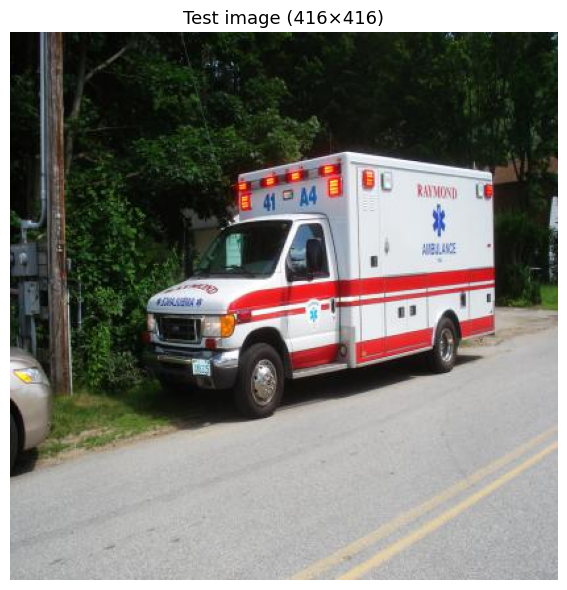

Size:  416×416 px, 3 channels (RGB)


In [401]:
image_path  = VAL_IMAGES / test_image

# Load with OpenCV
img_bgr = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img_rgb)
ax.set_title("Test image (416×416)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Size:  {img_rgb.shape[1]}×{img_rgb.shape[0]} px, {img_rgb.shape[2]} channels (RGB)")

---
## Step 1 — Vehicle Detection & Counting

In [402]:
# run inferenza sull'immagine test
results = model.predict(source=str(image_path), imgsz=IMG_SIZE, conf=CONFIDENCE_THRESHOLD, verbose=False)
result  = results[0]
boxes   = result.boxes

# numero di box
num_vehicles = len(boxes)
print(f"Vehicles detected: {num_vehicles}")

Vehicles detected: 2


### Visualize the detections

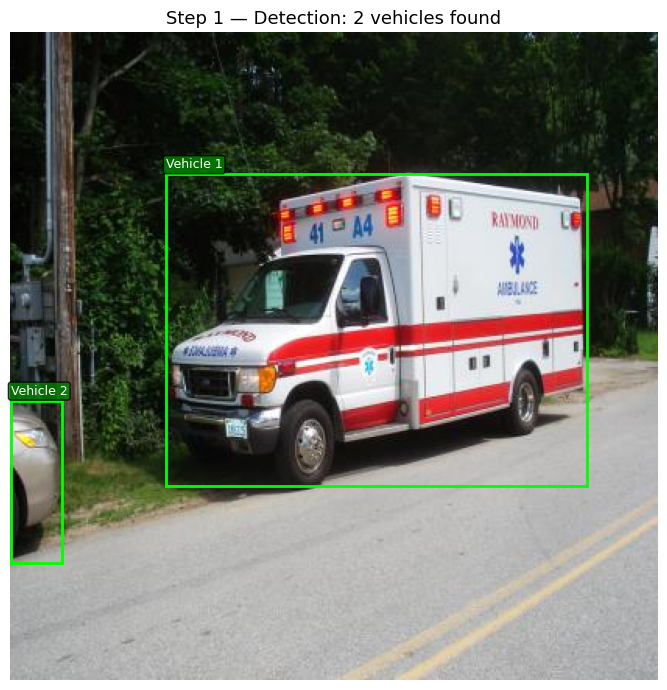

In [403]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(img_rgb)

for i, box in enumerate(boxes):
    # box.xyxy == pixel coordinates: [x1, y1, x2, y2]
    # (x1,y1) = top-left corner, (x2,y2) = bottom-right corner
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             linewidth=2, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, y1 - 4, f"Vehicle {i+1}",
            fontsize=9, color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="green", alpha=0.8))

ax.set_title(f"Step 1 — Detection: {num_vehicles} vehicles found", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Step 2 — Vehicle Classification

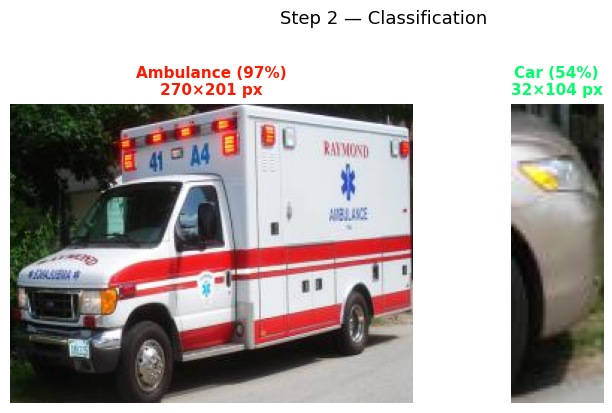

Vehicle         x1    y1    x2    y2   W×H (px)   Confidence
------------------------------------------------------------
Vehicle 1      100    91   370   291  270×200         97.1%
Vehicle 2        0   236    33   341   32×104         54.1%


In [404]:
n = len(boxes)
cols = min(n, 4)
rows = max(1, (n + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
if n == 1:
    axes = [axes]
elif n > 1:
    axes = axes.flatten()
else:
    axes = []

class_counts = Counter()

for i, box in enumerate(boxes):
    # Croppa dall'immagine originale usando le coordinate del box
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    cls_id   = int(box.cls[0])          # class index (0-4)
    cls_name = CLASS_NAMES[cls_id]       # class name
    conf     = box.conf[0].item()        # confidence score
    color    = CLASS_COLORS[cls_name]

    class_counts[cls_name] += 1

    # Crop the bounding box region
    crop = img_rgb[y1:y2, x1:x2]
    crop_h, crop_w = crop.shape[:2]

    axes[i].imshow(crop)
    axes[i].set_title(f"{cls_name} ({conf:.0%})\n{crop_w}×{crop_h} px",
                      fontsize=11, fontweight="bold", color=color)
    axes[i].axis("off")

# Hide unused subplots
for j in range(n, rows * cols):
    if j < len(axes):
        axes[j].axis("off")

fig.suptitle("Step 2 — Classification", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


print(f"{'Vehicle':<12} {'x1':>5} {'y1':>5} {'x2':>5} {'y2':>5} {'W×H (px)':>10} {'Confidence':>12}")
print("-" * 60)
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    conf = box.conf[0].item()
    w, h = int(x2 - x1), int(y2 - y1)
    print(f"Vehicle {i+1:<4} {x1:>5.0f} {y1:>5.0f} {x2:>5.0f} {y2:>5.0f} {w:>4}×{h:<4} {conf:>12.1%}")

---
## Full result: original vs annotated

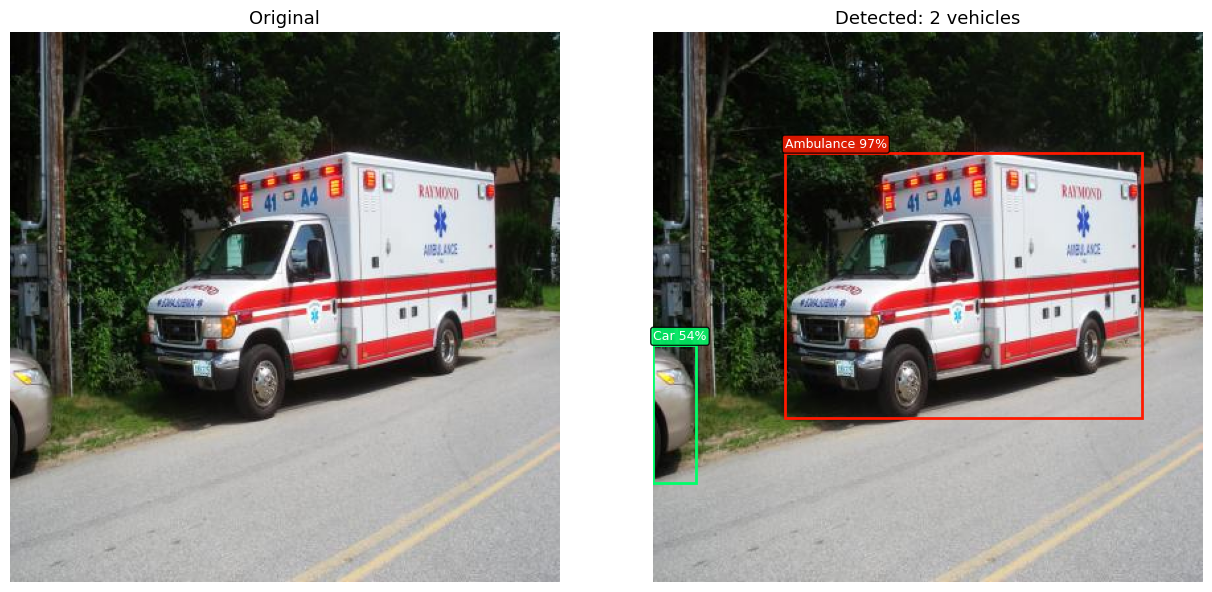

RESULT SUMMARY
Total vehicles detected: 2

  Ambulance       1
  Car             1


In [405]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: original image
axes[0].imshow(img_rgb)
axes[0].set_title("Original", fontsize=13)
axes[0].axis("off")

# Right: annotated with colored boxes and class labels
axes[1].imshow(img_rgb)
for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls_name = CLASS_NAMES[int(box.cls[0])]
    conf     = box.conf[0].item()
    color    = CLASS_COLORS[cls_name]

    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             linewidth=2, edgecolor=color, facecolor="none")
    axes[1].add_patch(rect)
    axes[1].text(x1, y1 - 4, f"{cls_name} {conf:.0%}",
                 fontsize=9, color="white",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.85))

axes[1].set_title(f"Detected: {num_vehicles} vehicles", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()



# Classification summary
print("=" * 40)
print("RESULT SUMMARY")
print("=" * 40)
print(f"Total vehicles detected: {num_vehicles}")
print()
for cls_name in CLASS_NAMES:
    count = class_counts.get(cls_name, 0)
    if count > 0:
        print(f"  {cls_name:<15} {count}")
print("=" * 40)

## Model Performance

Run the evaluation first, then skim the three plots (training curves, confusion matrix, PR curves).

In [406]:
!python3 src/02_evaluate.py


--- Evaluation on TEST set ---

Ultralytics 8.4.19 🚀 Python-3.14.0 torch-2.10.0 CPU (Apple M3 Pro)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 81.9±16.6 MB/s, size: 29.5 KB)
val: Scanning /Users/paolodeidda/Documents/UNI/Master/Tesi/Vehicle Counting Model/data/test/labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 18.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.4s1.0ss
                   all        126        258      0.943      0.579      0.762      0.638
             Ambulance         18         18      0.956          1      0.995       0.97
                   Bus         22         38          1      0.642      0.848      0.697
                   Car         60        150      0.939       0.44      0.689      0.522
            Motorcycle         12         32      0.822      0.312

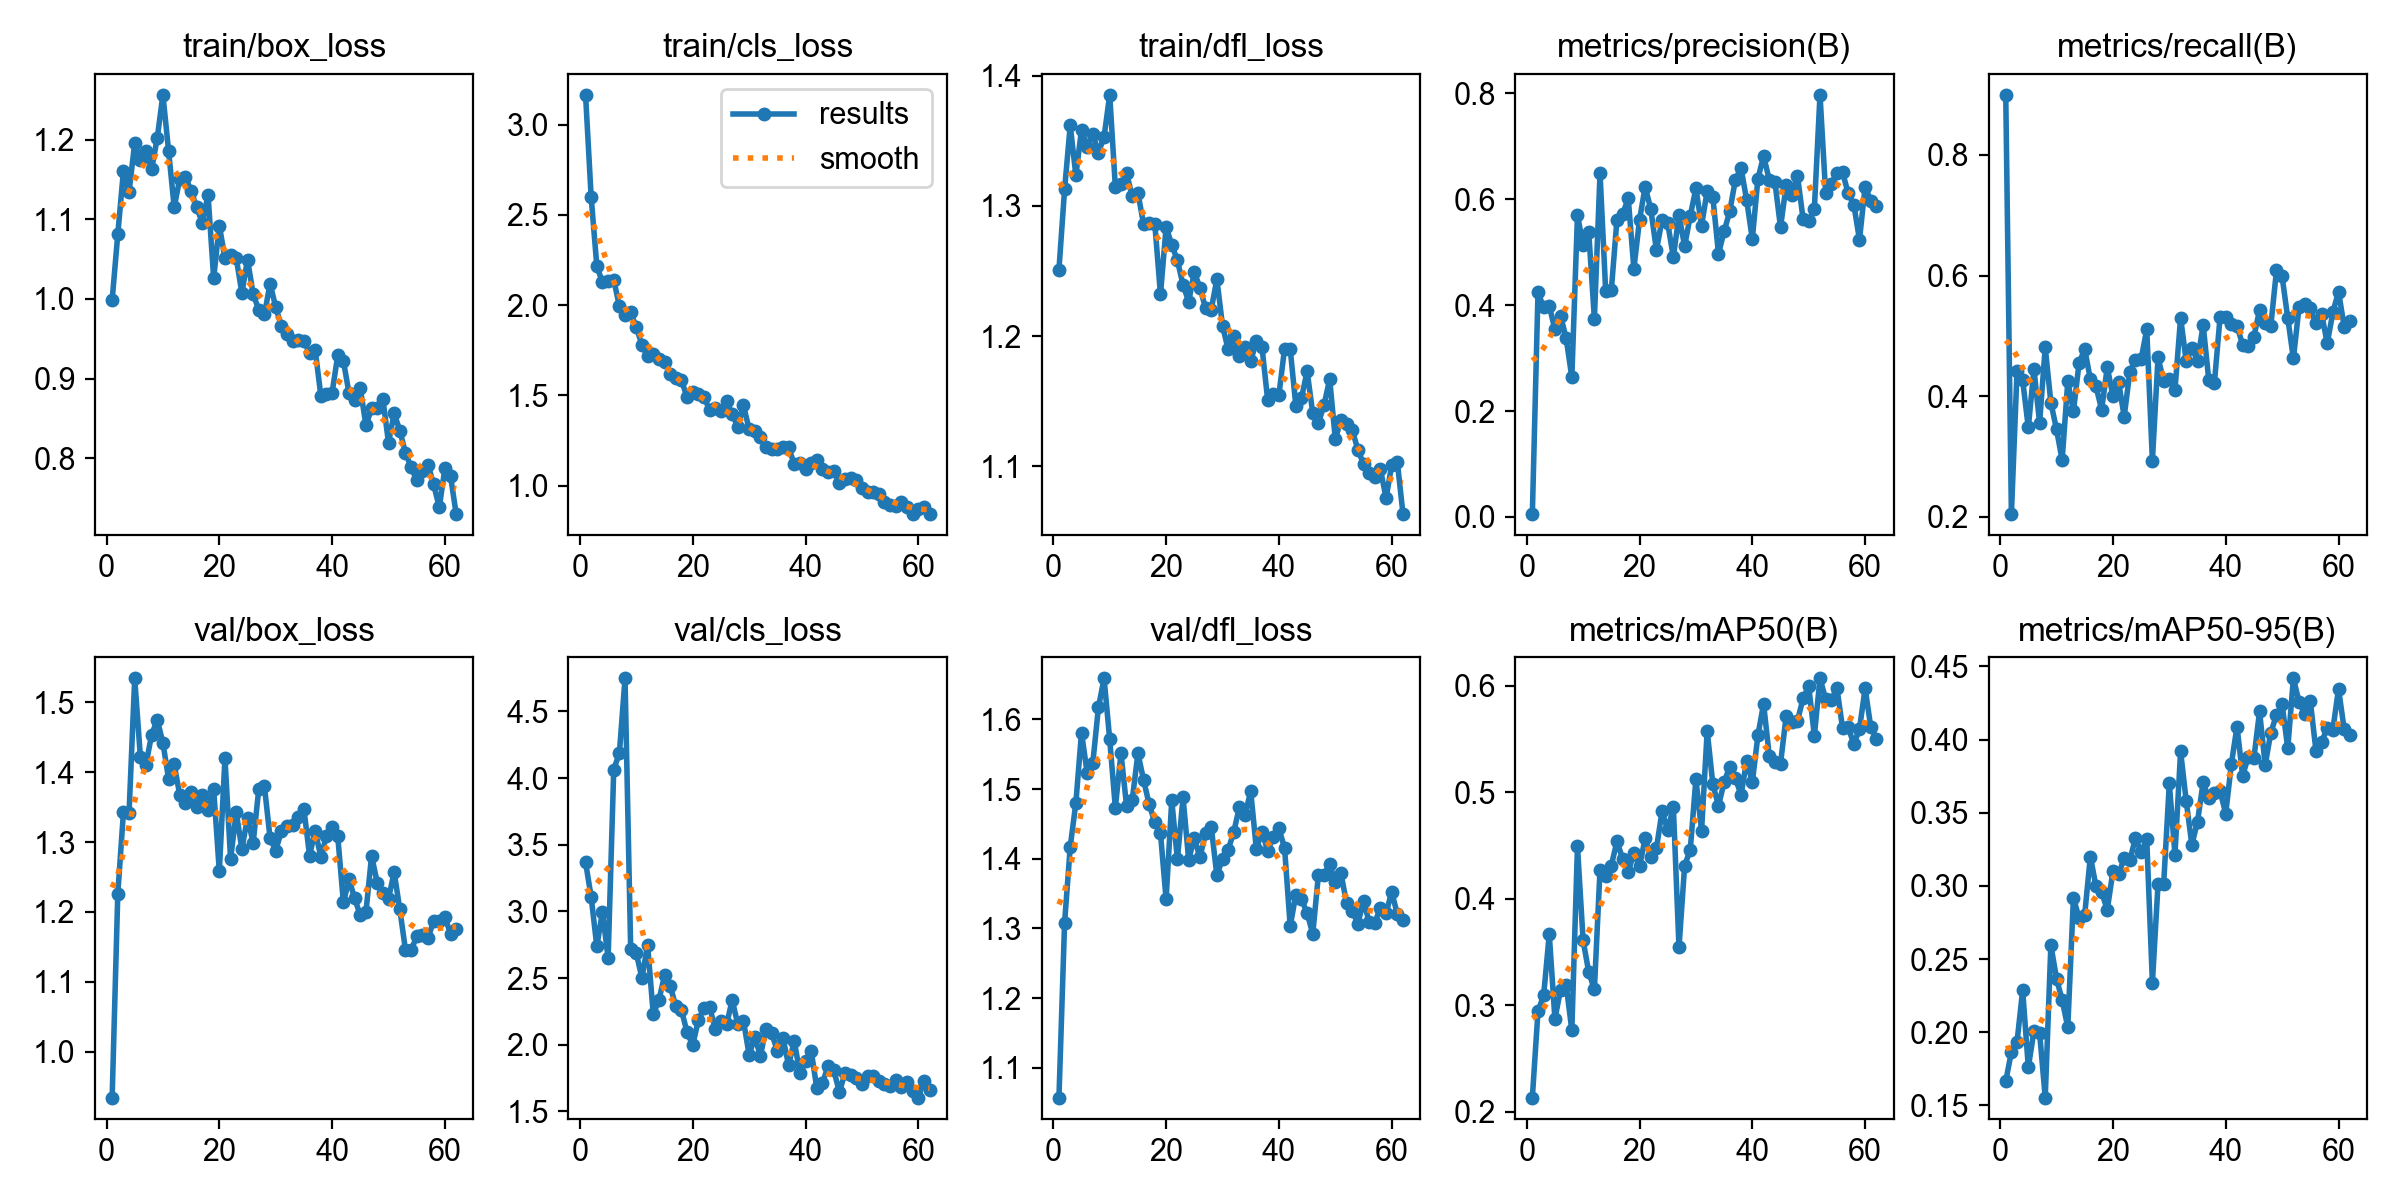

In [ ]:
from IPython.display import Image, display

training_curves = training_dir / "results.png"
display(Image(filename=str(training_curves), width=800))

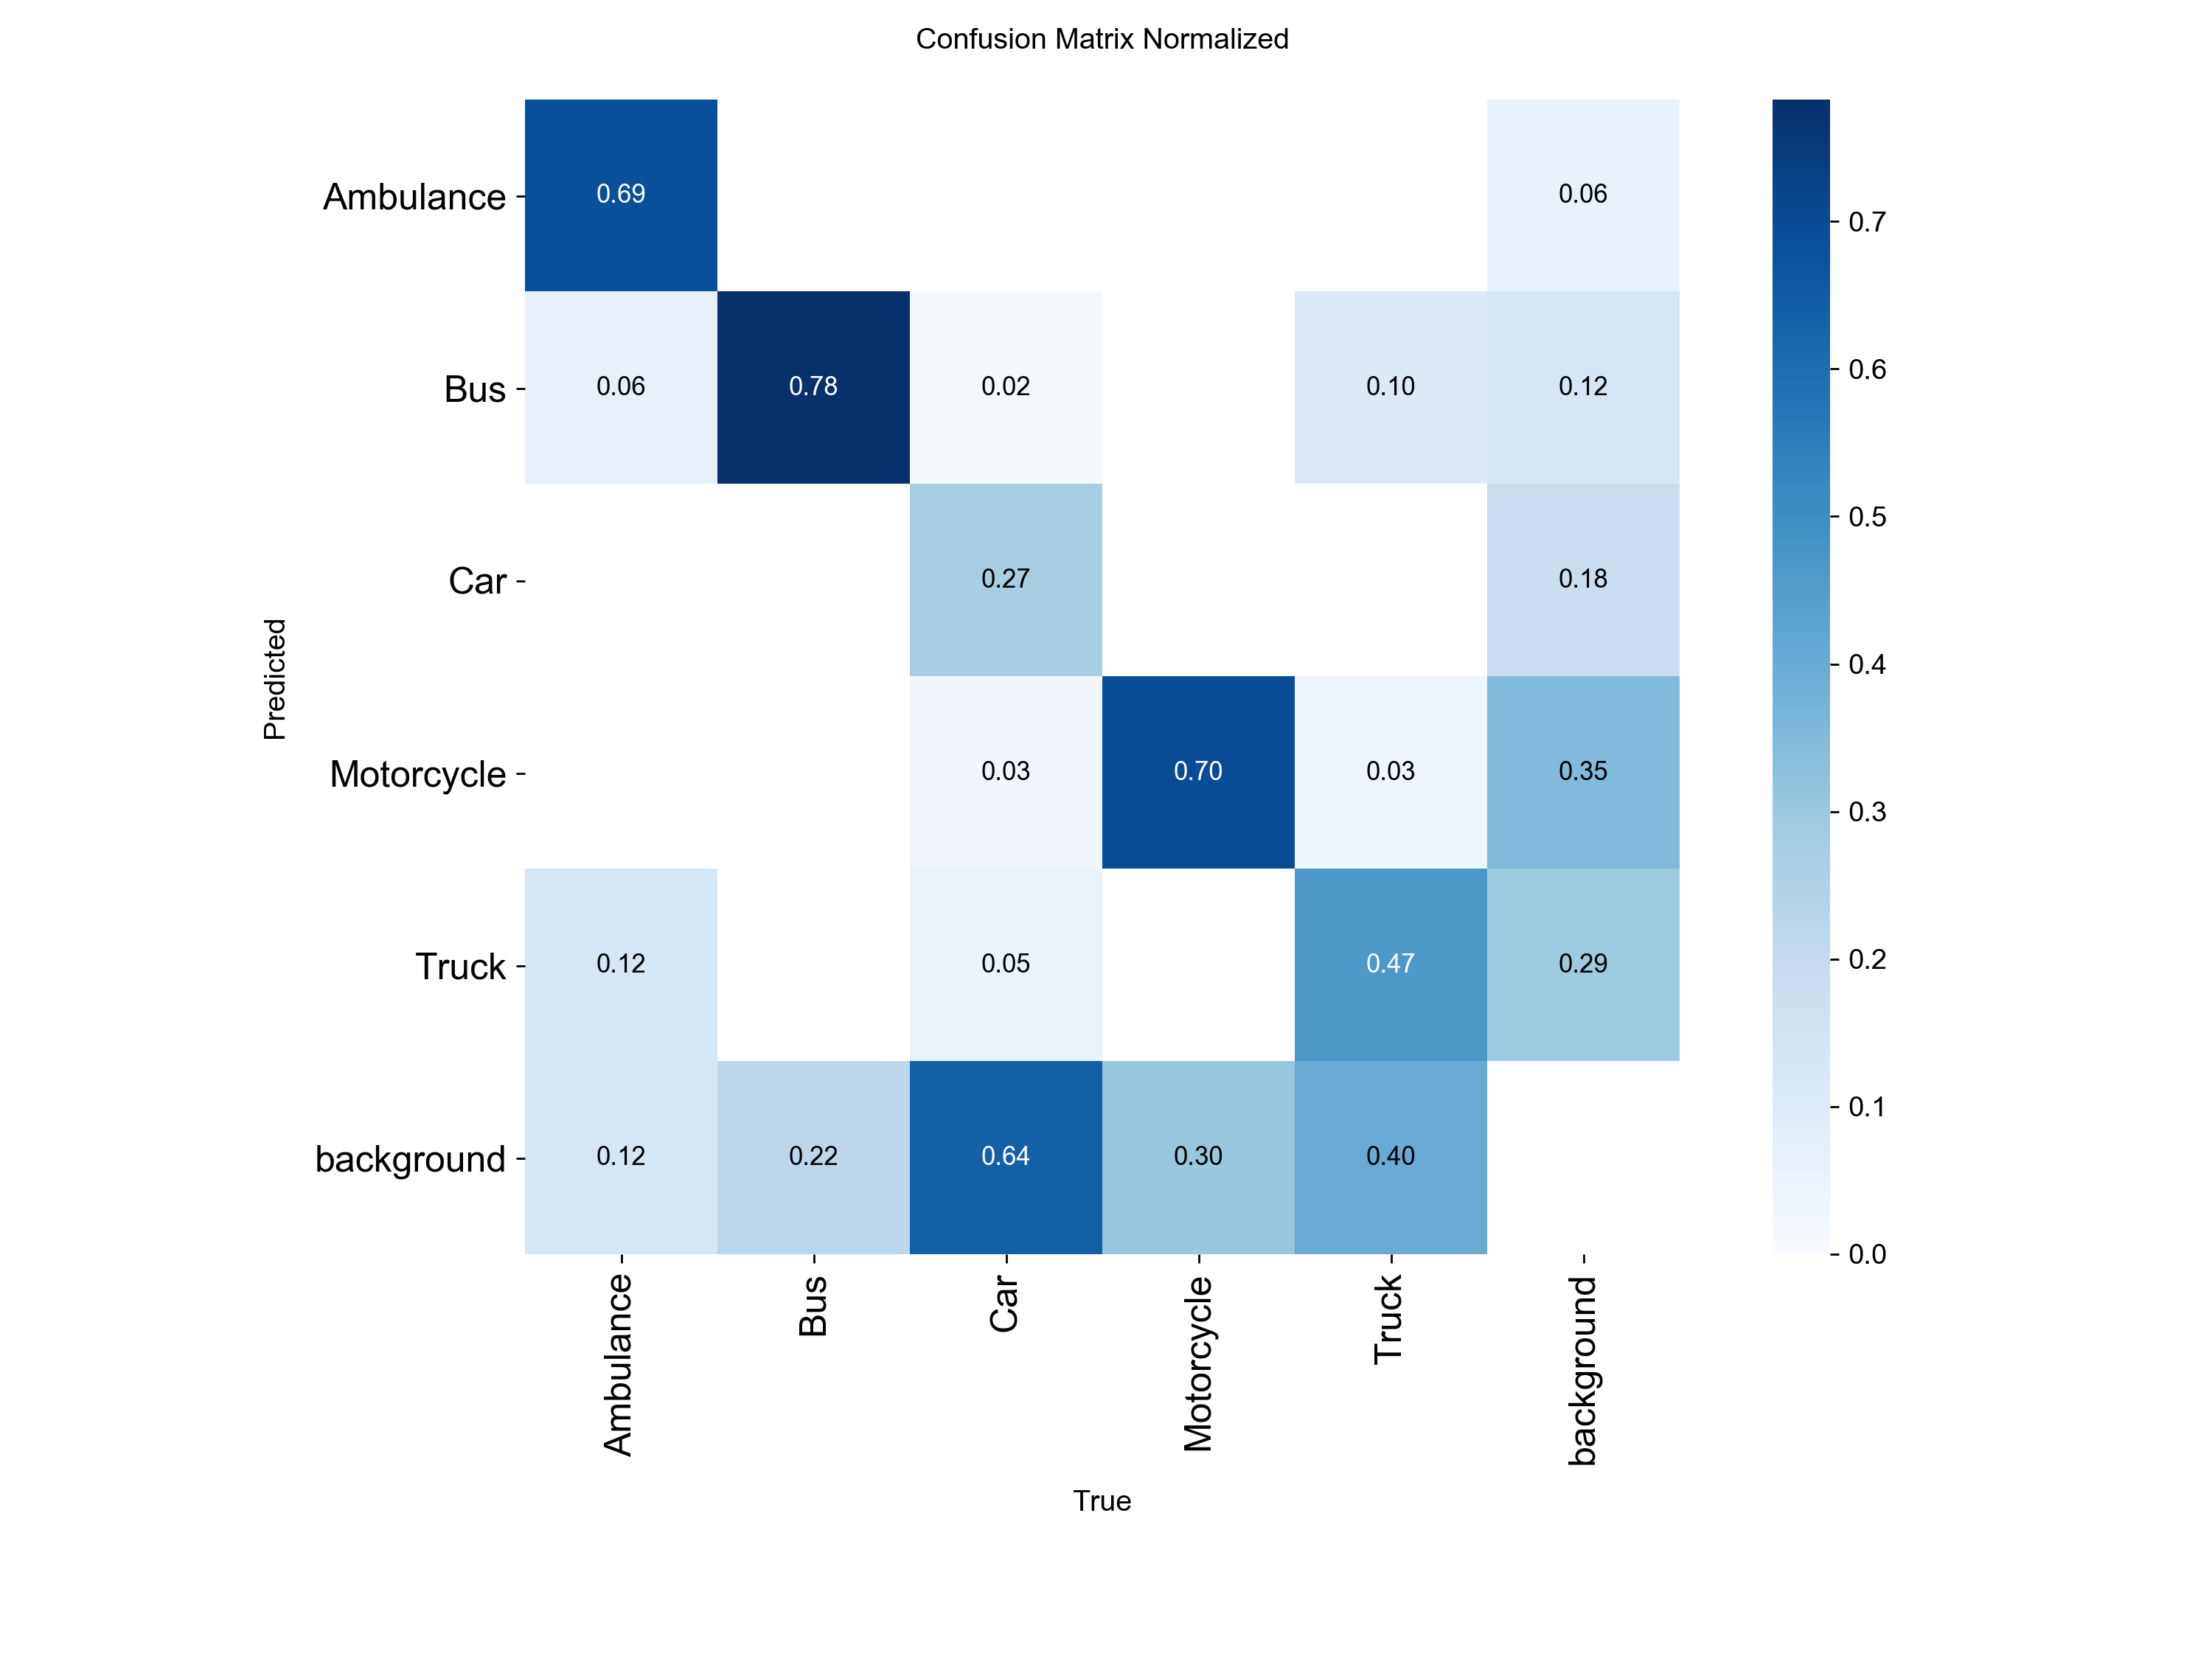

In [411]:
# Confusion matrix (normalized by column)
conf_mat = training_dir / "confusion_matrix_normalized.png"
display(Image(filename=str(conf_mat), width=550))

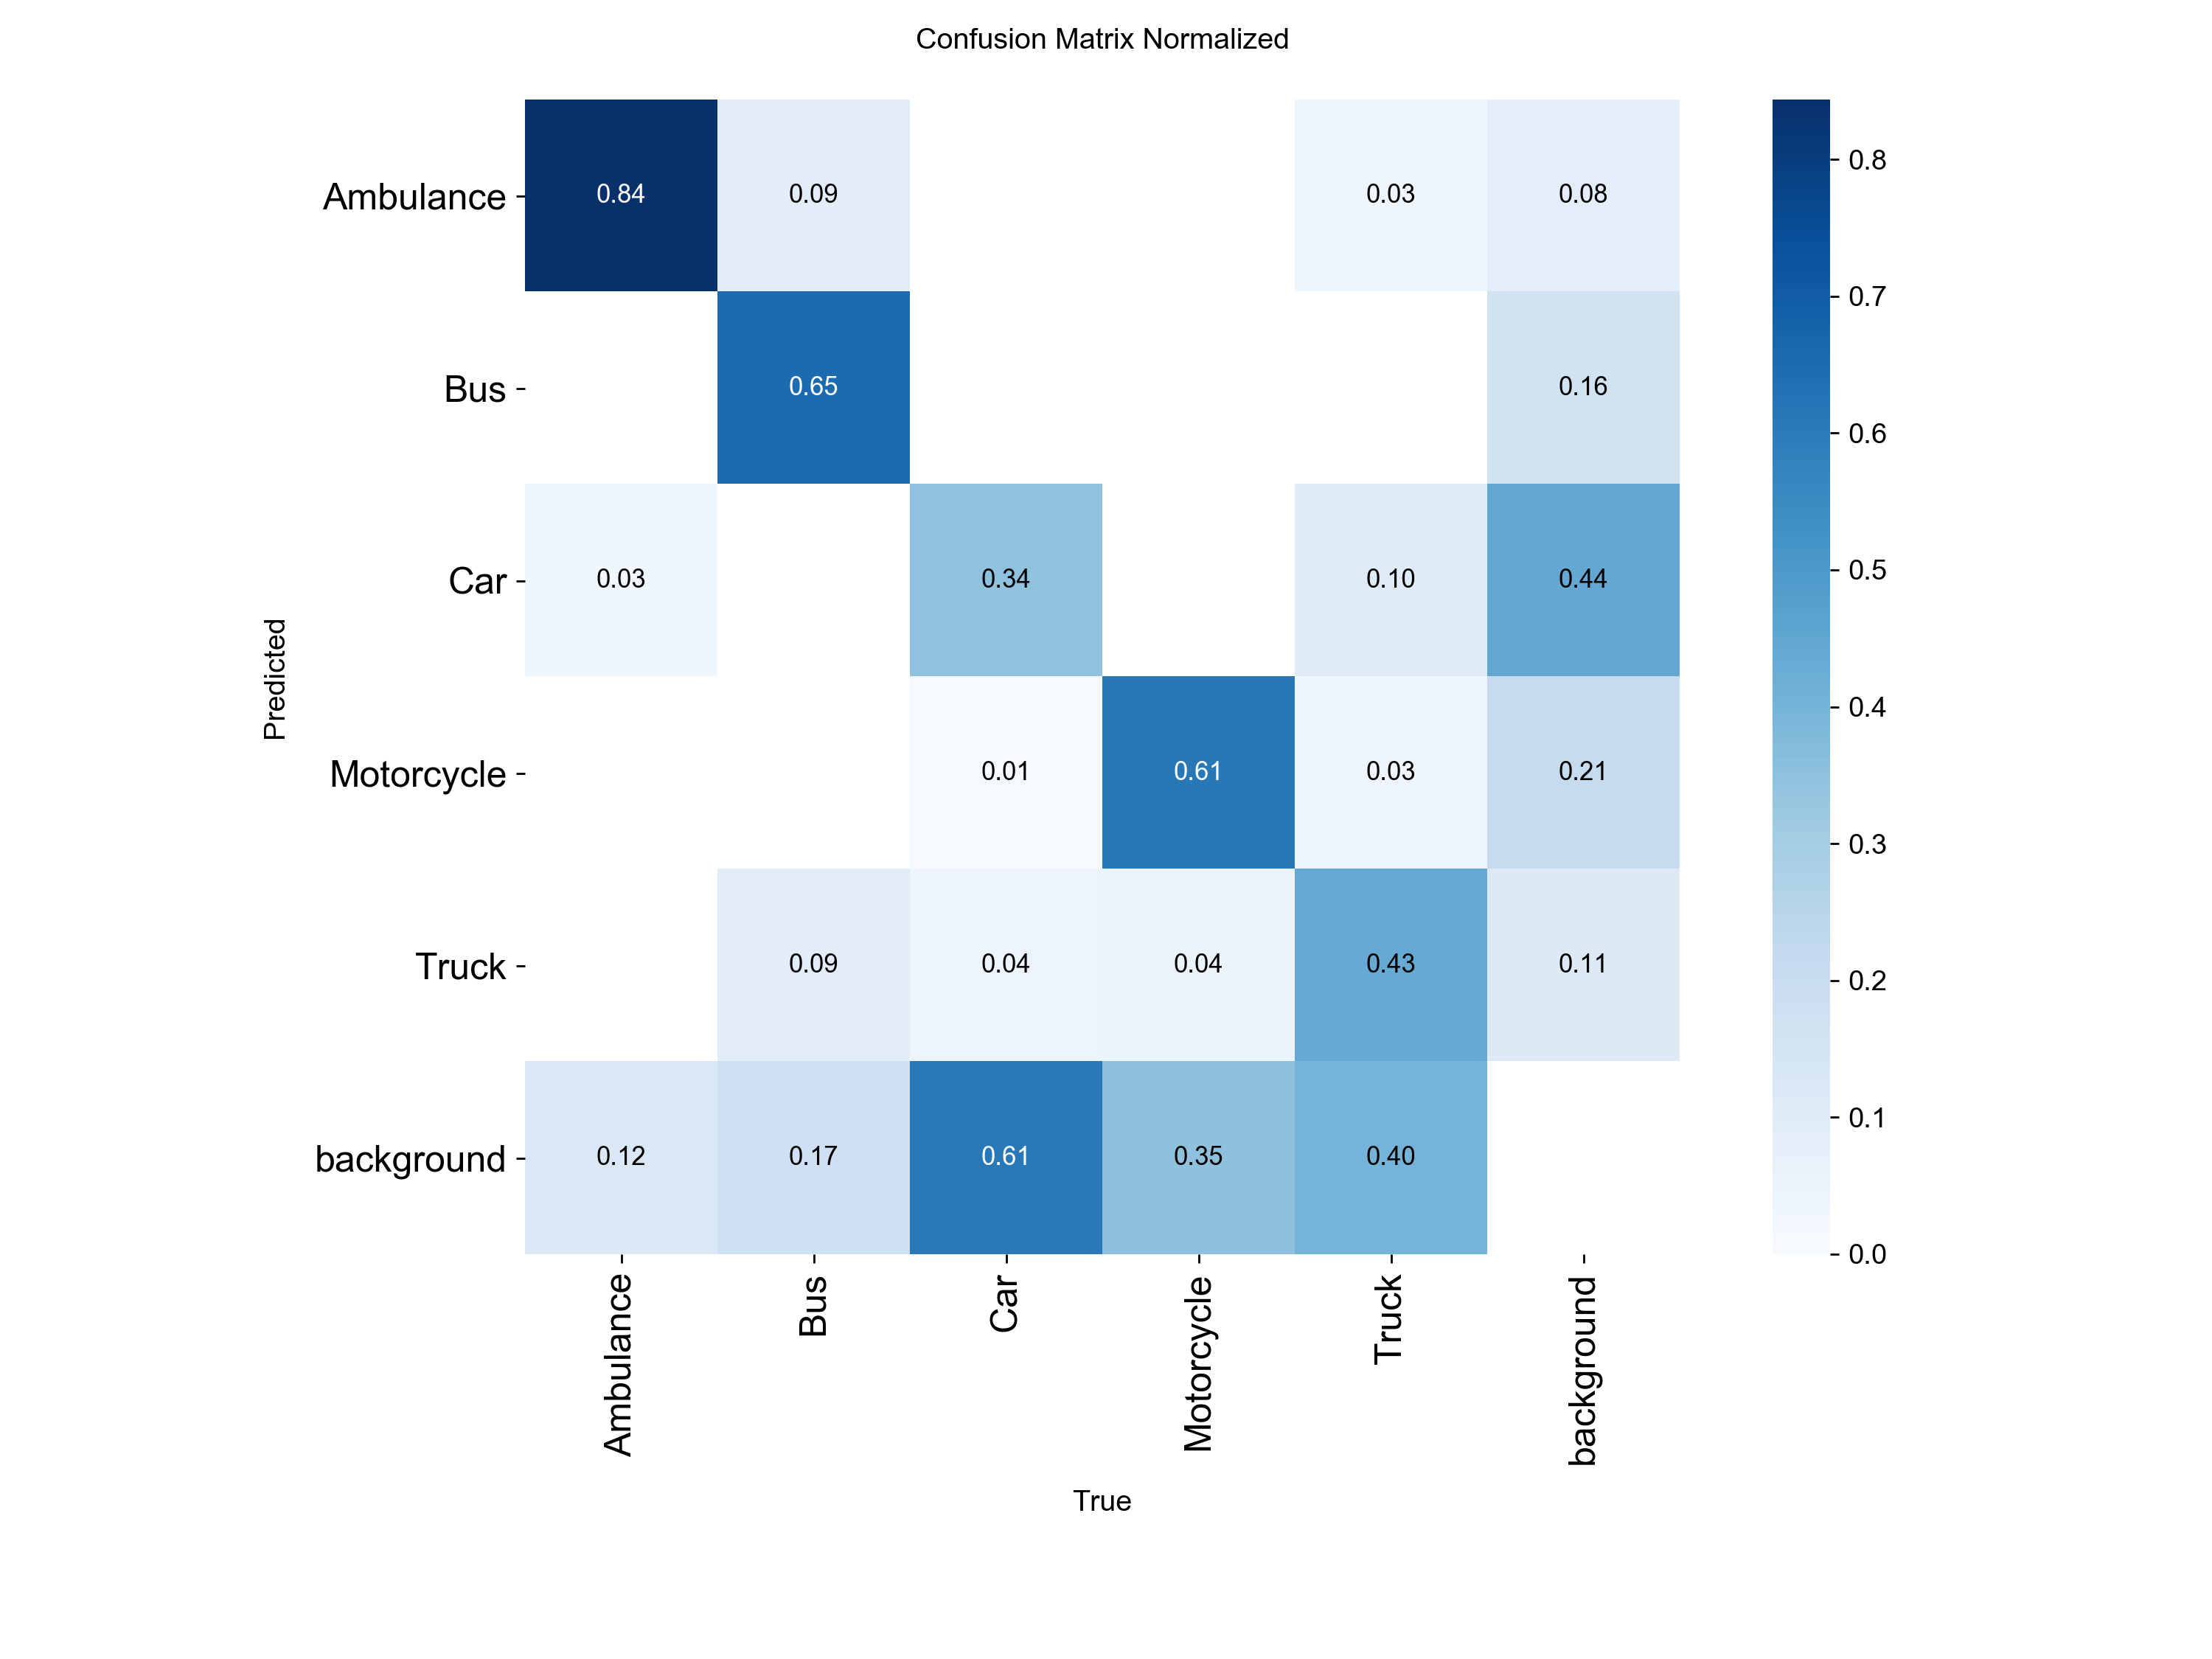

In [412]:
display(Image(filename=str(PROJECT_ROOT / "runs" / "vehicle_detection_balanced_50ep" / "confusion_matrix_normalized.png"), width=550))

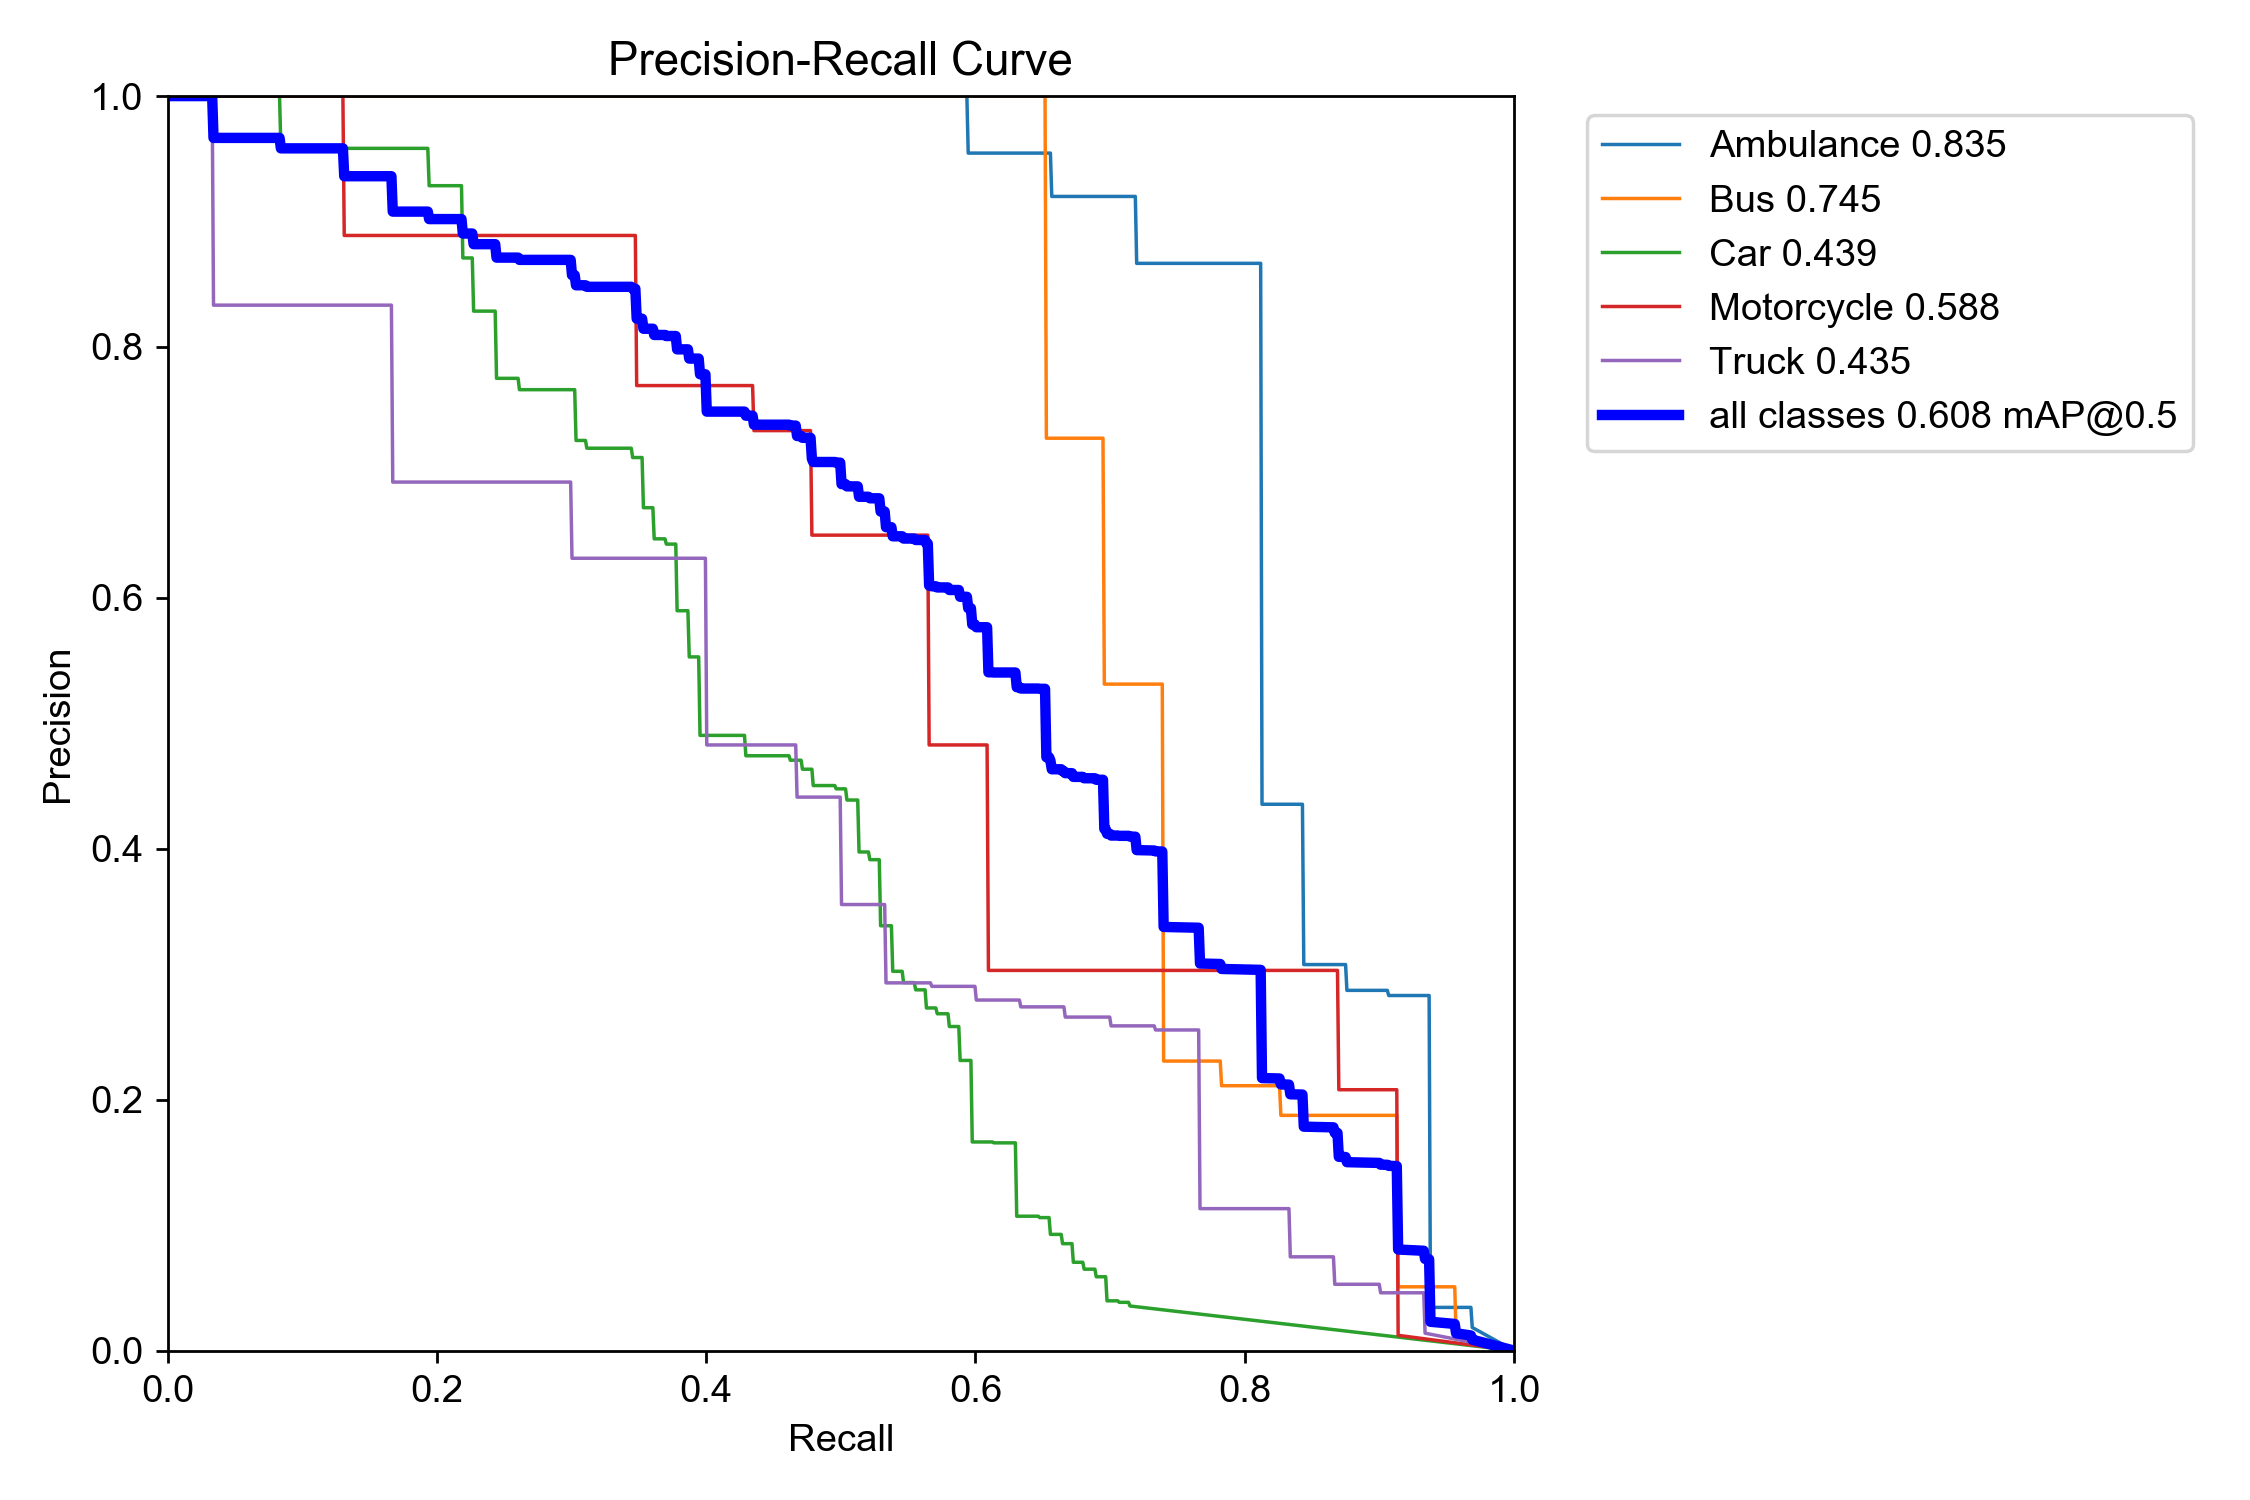

In [409]:
# Precision–Recall curves (per class and mean)
pr_curve = training_dir / "BoxPR_curve.png"
display(Image(filename=str(pr_curve), width=550))